In [34]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset , DataLoader
from torch.nn import MSELoss
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('powerplant_data.csv')
df.head()
# AT -> temp value
# V  -> vaccum value
# AP -> Pressure
# RH -> Humdity
# PE -> Produced Energy and output

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop(columns='PE')
y = df['PE']

In [8]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Convert Data into Tensors

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled , dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled , dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values , dtype=torch.float32).view(-1,1) # it is pandas series , view -> change dimensions[ r, c ]
y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32).view(-1,1)

# y_train -> shape (n,)   1D
# pytorch shape needed -> (n,1)  [ -1 -> auto detect rows , 1 -> no of cols]
# to build correct tensor
# tensors stored on ram on this system

### TensorDataset and DataLoader

In [17]:

train_dataset = TensorDataset(X_train_tensor , y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor , y_test_tensor) 

In [18]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True)
test_loader  = DataLoader(test_dataset , batch_size=32)

### ANN Model

In [29]:
# Define the model / architecture

class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1] , 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6 , 1)
        )

    def forward(self , x):
        return self.model(x)
    

In [30]:
model = ANN()

# loss fnx and optimizer
crieterion = MSELoss()
optimizer = optim.Adam(model.parameters())

In [31]:
# Train ANN Model

epochs = 100
train_losses = []
valid_losses = []

best_validation_loss = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0           # total traning loss for one epoch

    for xb,yb in train_loader:   # giving every batch xb -> input features of one batch , yb -> labels of one batch

        optimizer.zero_grad()    # remove previous gradients and fresh new are calculated

        outputs = model(xb)      # predicted output for this batch ith batch.... forward_prop

        loss = crieterion(outputs , yb)

        loss.backward()          # compute gradients.... back prop .... weight updation k liye gradient

        optimizer.step()         # update parameter ... weight and bias

        running_loss += loss.item()         #loss is tensor -> python float


    # avg loss per batch for 1 epoch [ running_loss / total batches]

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():   # no gradients compute here
        for xb , yb in test_loader:
            outputs = model(xb)
            loss = crieterion(outputs , yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)


    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} and validation loss = {epoch_val_loss}")

    if epoch_val_loss < best_validation_loss:
        best_validation_loss = epoch_val_loss
        torch.save(model.state_dict() , "best_model.pt")    #.pt /.pth
    

epoch 1/100 ==> training loss = 204963.86080729167 and validation loss = 200959.328125
epoch 2/100 ==> training loss = 190306.94498697916 and validation loss = 173946.390625
epoch 3/100 ==> training loss = 148626.903125 and validation loss = 118963.625
epoch 4/100 ==> training loss = 89074.35594075521 and validation loss = 61277.53515625
epoch 5/100 ==> training loss = 43158.29013671875 and validation loss = 30124.55078125
epoch 6/100 ==> training loss = 23547.565873209634 and validation loss = 19297.6484375
epoch 7/100 ==> training loss = 16488.94222208659 and validation loss = 14539.71875
epoch 8/100 ==> training loss = 12649.580497233073 and validation loss = 11182.8466796875
epoch 9/100 ==> training loss = 9603.010874430338 and validation loss = 8385.2216796875
epoch 10/100 ==> training loss = 7115.992660522461 and validation loss = 6109.63916015625
epoch 11/100 ==> training loss = 5179.323435465495 and validation loss = 4403.52978515625
epoch 12/100 ==> training loss = 3737.230978

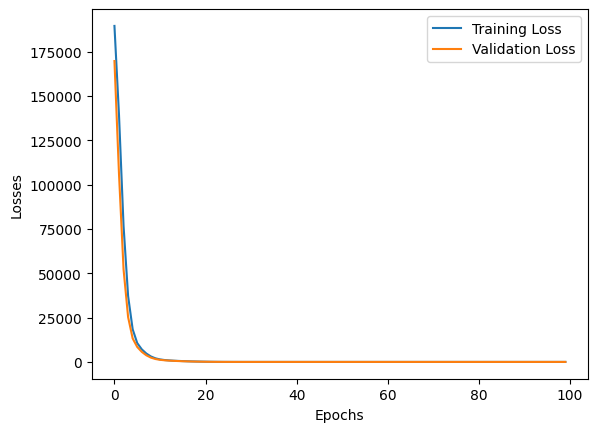

In [28]:
loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss"   : valid_losses
})

plt.plot(loss_df["Training Loss"] , label = "Training Loss")
plt.plot(loss_df["Validation Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

### Saving and Loading the best Model

In [32]:
# validation loss -> new/unseen data minimize loss

# Loading the best Model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [35]:
# Evaluate Model
# 1) MSE -> Training and Testing 
# 2) R2 score

model.eval()

with torch.no_grad():
    training_pred = model(X_train_tensor)
    testing_pred = model(X_test_tensor)

    train_mse_loss = crieterion(training_pred , y_train_tensor)
    test_mse_loss = crieterion(testing_pred , y_test_tensor)

print("Traning MSE :" , train_mse_loss.item())
print("Testing MSE :" , test_mse_loss.item())

print("R2 Score :" , r2_score(y_test , testing_pred))

Traning MSE : 20.548768997192383
Testing MSE : 18.76890754699707
R2 Score : 0.9344075169009445
